In [ ]:
from langgraph.graph import START, END, StateGraph, MessagesState
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from IPython.display import Markdown, display
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model='qwen3.8:27b', 
    temperature=0,
    model_provider='ollama'
)

display(Markdown(llm.invoke("hi? repond wth blue color").content))

<span style="color: blue">Hi! 👋</span>

*(Note: I can't actually change the color of my text in this chat interface — it depends on how your platform renders messages. But I tried! If you're looking for a specific blue-themed response or need help with something, just let me know.)*

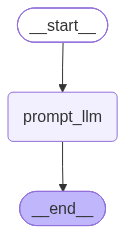

In [17]:
from langchain.messages import AIMessage, HumanMessage, SystemMessage
from IPython.display import Image, display

def prompt_llm(state: MessagesState):
    # MessagesState has exactly ONE key: "messages". Both the read and the
    # returned update have to use it -- a different key is a KeyError going in
    # and an InvalidUpdateError coming out.
    response = llm.invoke(state['messages'])
    # Returning a single message is fine: the add_messages reducer on this key
    # APPENDS it to the list rather than replacing the history.
    return {'messages': response}


graph_builder = StateGraph(MessagesState)

graph_builder.add_node(prompt_llm)
# add_edge takes node NAMES, not the function object. add_node(prompt_llm)
# registered it under its __name__, so that string is the handle.
graph_builder.add_edge(START, "prompt_llm")
graph_builder.add_edge("prompt_llm", END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
# Two rules, both violated by graph.invoke(["hello"]):
#   1. the input is a STATE UPDATE, so it must be a dict, not a bare list;
#   2. the key is "messages" -- MessagesState declares exactly that one key, and
#      the name is not yours to pick. Use a custom state class if you want "msg".
# The add_messages reducer coerces the plain string into a HumanMessage for you.
result = graph.invoke({"messages": "hello"})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

hello
================================== Ai Message ==================================

Hello! How can I help you today?
